In [454]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

### Q6 Exercise Week 8 (Filtering)

Overview of relevant material from the tutorials and exercises related to filtering in image processing and computer vision:
- [08 Tutorial](../Tutorials/08-filters.ipynb)
    - blur filter (gaussian and mean) for noise reduction
    - partial derivatives for edge detection using filters
    - convolving blur+edge-filter with image
- filtering gaze data (W08 01)
    - gaussian filter for smoothing noisy gaze data (Task 2-4)
    - partial derivatives filter for detecting saccades (Task 5-9)
    - identification of individual fixations using detected saccades (Task 10-13)
    - analyzing results (Task 14-15)
    - using combined signal (Task 17-18)
- filter basics (W08 02)
    - shifting pixels using filters (Task 1)
    - blurring using gaussian filter (Task 2)
    - template matching of sunflower (Task 3)
    - sharpening filter (Task 4)
    - sobel filters (Task 5)
    - convolution implementation (Task 6)
+ maybe some HOG features exercises from week 11?
    - HOG feature extraction and how to measure similarity (W11 03)
    - HOG for face detection (W11 04)

#### (a) Focus on filtering (1D, 2D, and n-D convolution and correlation, blurring and smoothing, and noise).
- Gaussian and mean filters for noise reduction (W08 Tutorial)
- Convolution for applying filters (W08 Tutorial)
- Correlation for template matching (W08 02 Task 3)
- Implementation of 2D convolution (W08 02 Task 6)
- Use case: W08 01
    - Gaussian filter for smoothing noisy gaze data (Task 2-4)
    - Partial derivatives filter for detecting saccades (Task 5-9)
    - Identification of individual fixations using detected saccades (Task 10-13)
    - Analyzing results of filtering (Task 14-15)
    - Using combined signal for improved filtering (Task 17-18)


#### (b) Focus on filtering for derivatives, gradients, and edges. You may include how these operations can be used to construct features such as HOG.
- Partial derivatives for edge detection using filters (W08 Tutorial)
- saccade detection using partial derivatives filter (W08 01 Task 5-9)
- combined signal for improved saccade detection (W08 01 Task 17-18)
- HOG feature extraction and similarity measurement (W11 03)
- HOG for face detection (W11 04)

In [455]:
import filtering_util
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pandas as pd

# Filtering gaze data
This exercise introduces different techniques for processing and analyzing gaze data using filtering. In particular the exercise removing noise and identifying fixations and saccades in the signal. A _fixation_ is defined as an instance with little or no eye movement. A _saccade_ is an eye movement between two fixations as illustrated in [Figure 1](#fix_sacc) for an example (image from [researchGate](https://www.researchgate.net/publication/356796000_TECHNICAL_MANUALS_READING_STRATEGIES_OF_PRIMARY_TEACHER_TRAINESS/figures?lo=1)
).
<div class="has-text-centered">
<figure class="image is-inline-block" id="fix_sacc">
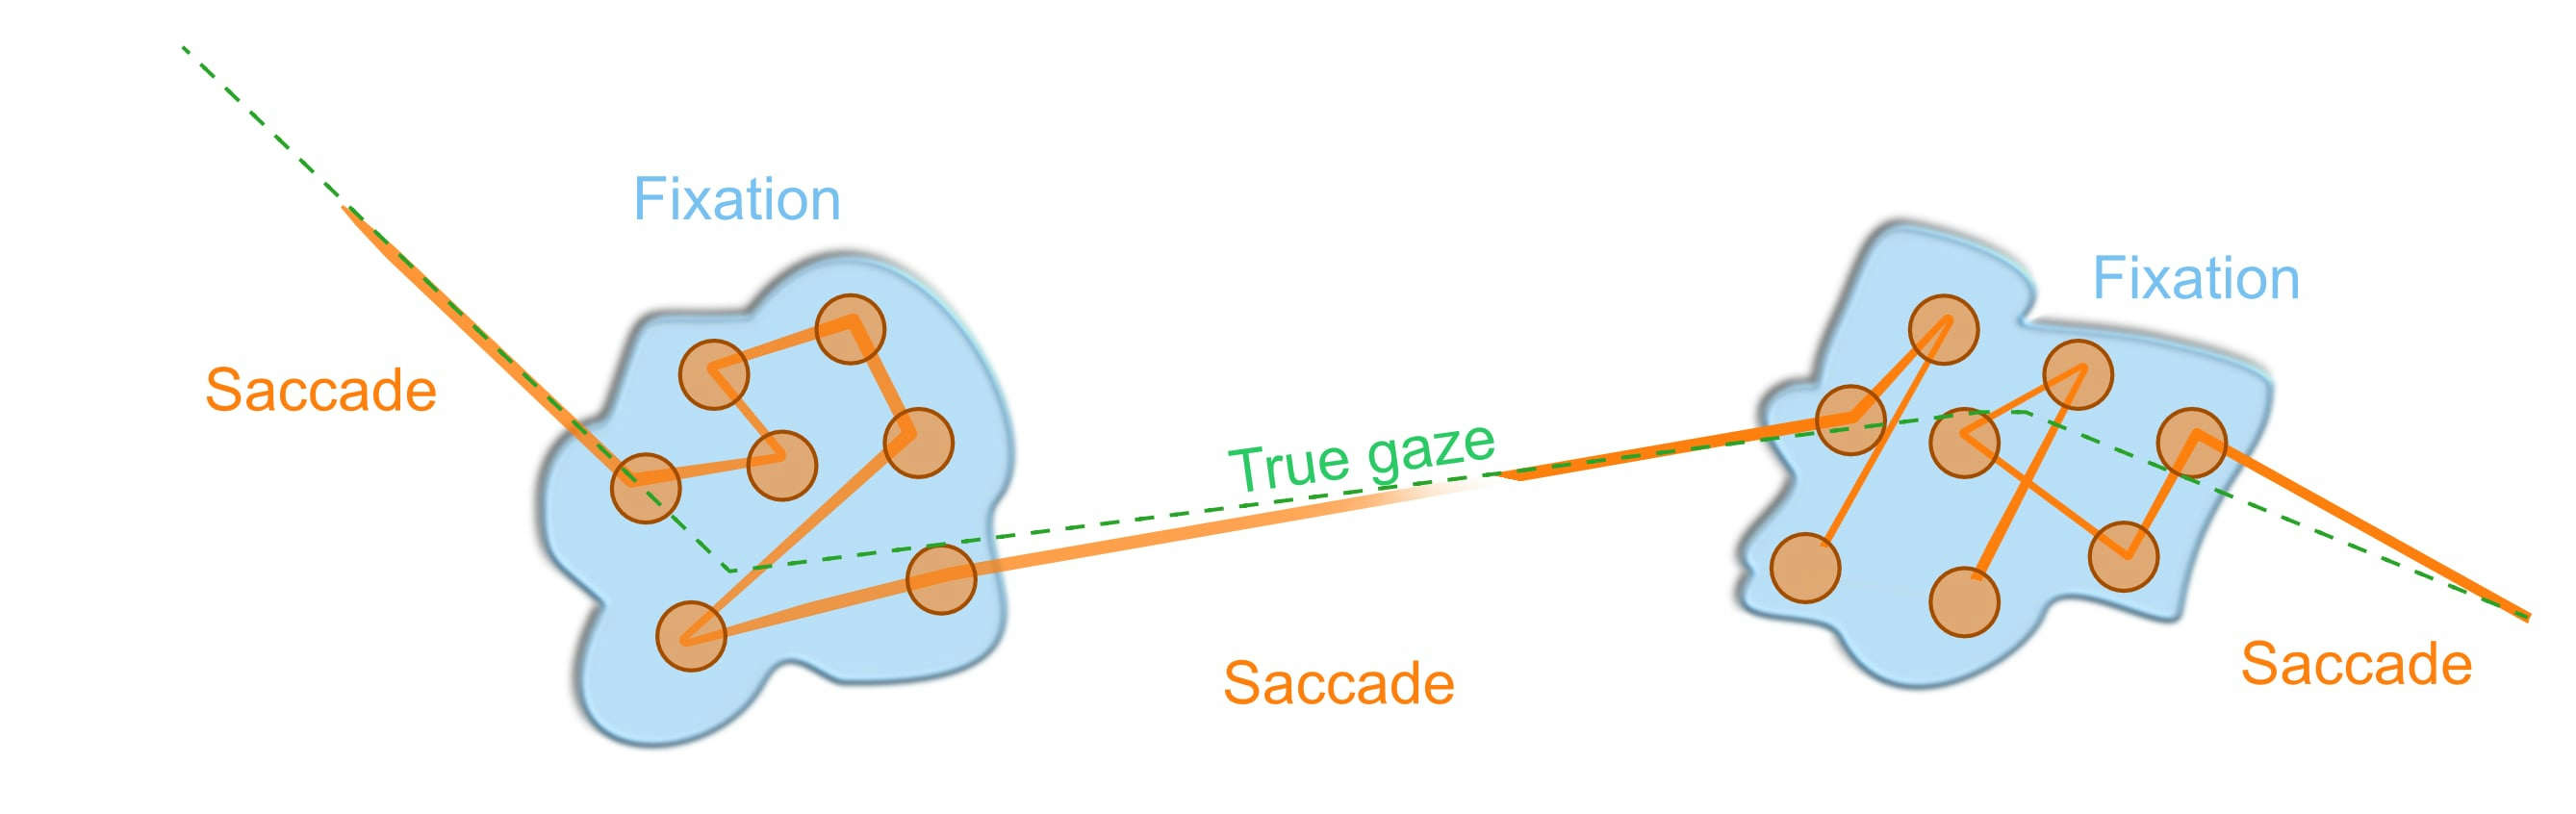

<figcaption class="figure-caption has-text-centered">Figure 1: Fixation and saccades in gaze data.
</figcaption>
</figure>
</div>
The visualizations presented throughout the exercise are based on data collected from `test_subject_1`
 using the `grid` pattern.
The exercise contains functions in the `filtering_util.py` file to create plots. 


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#task_load_data">Task 1: Load the data</a>
            </li>
            <li>
            <a href="#task_gauss1">Task 2: Gaussian filter</a>
            </li>
            <li>
            <a href="#task_gauss2">Task 3: Implementing gaussian filter</a>
            </li>
            <li>
            <a href="#task_gauss3">Task 4: Reflect on applying gaussian filter</a>
            </li>
            <li>
            <a href="#task_gauss4">Task 5: Partial derivatives</a>
            </li>
            <li>
            <a href="#partial1">Task 6: Calculate the derivatives</a>
            </li>
            <li>
            <a href="#partial2">Task 7: Derivatives of a signal</a>
            </li>
            <li>
            <a href="#partial3">Task 8: Saccade detection</a>
            </li>
            <li>
            <a href="#partial4">Task 9: Saccade detection</a>
            </li>
            <li>
            <a href="#fixations1">Task 10: Fixation detection</a>
            </li>
            <li>
            <a href="#fixations2">Task 11: Visualization of signals</a>
            </li>
            <li>
            <a href="#fixation3">Task 12: Noise handling during fixations</a>
            </li>
            <li>
            <a href="#fixation4">Task 13: Frame grouping</a>
            </li>
            <li>
            <a href="#results1">Task 14: Evaluate</a>
            </li>
            <li>
            <a href="#owndata">Task 15: Combined signal</a>
            </li>
            <li>
            <a href="#combined1">Task 16: Combined signal</a>
            </li>
            <li>
            <a href="#combined2">Task 17: Reflect</a>
            </li>
        </ul>
    </div>
</article>

**Note:** Although the number of tasks is substantial, each requires minimal programming effort, with many tasks primarily necessitating reflection on the outcomes.


---
**Task 1 (easy): Load the data👩‍💻**
1. Run the cell to visualize the `grid`
 pattern of `test_subject_1`
.
**Note:** The code is loading the data from the folder of week 6. Alternatively you can copy the data to the folder of this exercise and change the file path accordingly.




---

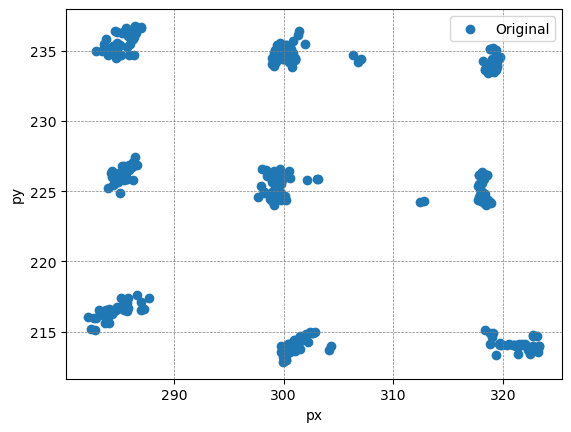

In [456]:
test_subject = 'test_subject_1' 
trial = '20250820_T0'
pattern = 'grid'

# own data:
#test_subject = 'mbko'
#trial = '20250908_T1'

pupil_coordinates =f'../IML_Assignments/GazeEstimation/W02/sessions/{test_subject}/{trial}/{pattern}/frames/pupil_coordinates.csv'
mean_pupil_coordinates = f'../IML_Assignments/GazeEstimation/W02/sessions/{test_subject}/{trial}/{pattern}/mean_pupil_coordinates.csv'


pupil_coor= filtering_util.load_csv1(pupil_coordinates)


filtering_util.plot_pupil_coor(pupil_coor['px'], pupil_coor['py'], 'Original')
plt.show()

The next task involves visualizing the pupil coordinates signals `px`
 and `py`
 for the gaze `grid`
 pattern. In this task, a $1D$ Gaussian filter will be applied to smooth the signals individually. [Figure 2](#gauss) illustrates the Gaussian $1D$ filters and the corresponding filtered signal. The cell below convolves a Gaussian filter to gaze data. 
<div class="has-text-centered">
<figure class="image is-inline-block" id="gauss">
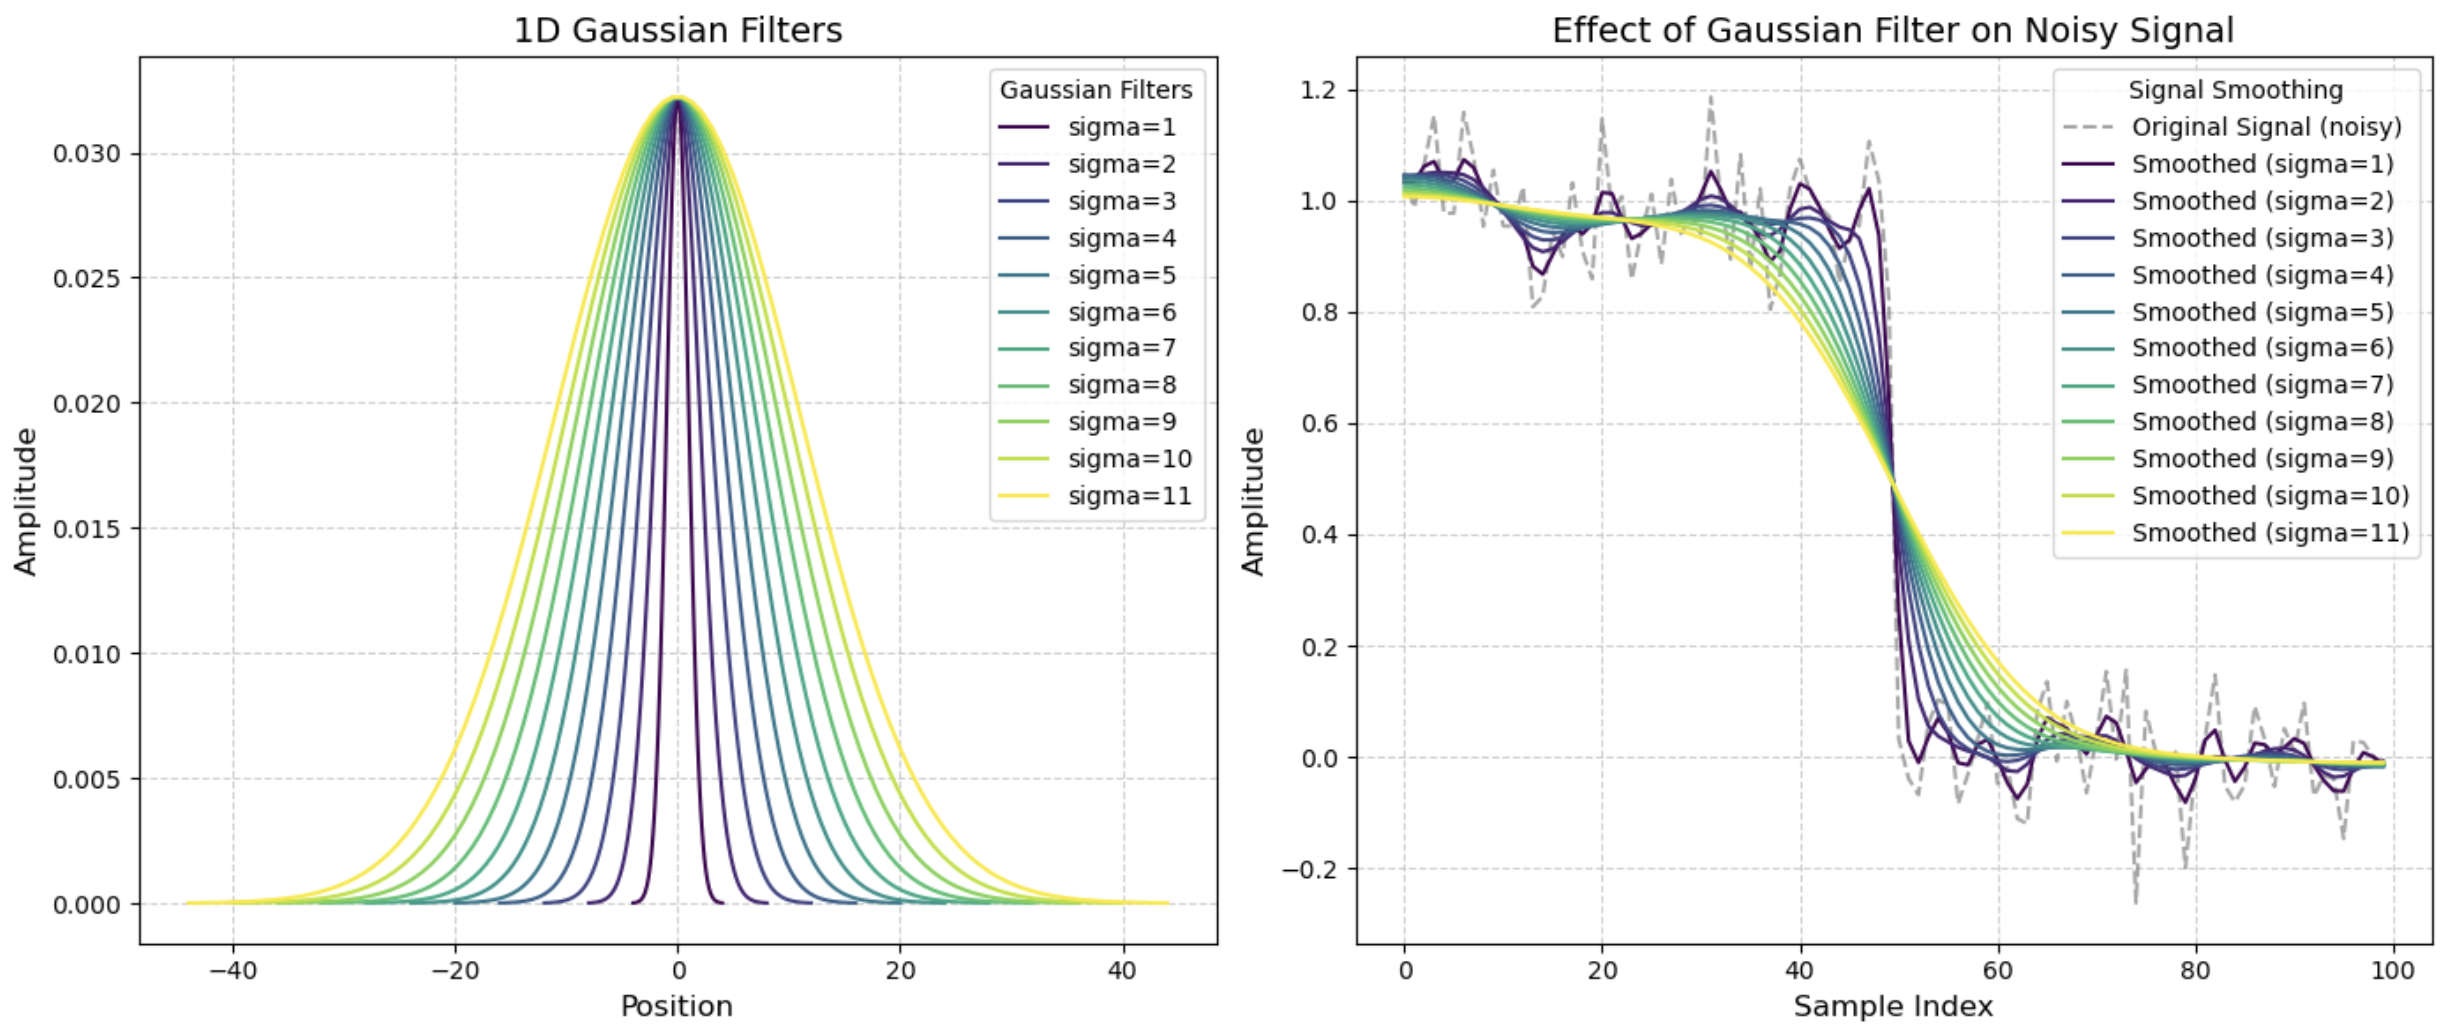

<figcaption class="figure-caption has-text-centered">Figure 2: Left: Shows the shape of the Gaussian filter for each value of sigma. Right: Demonstrates the effect of smoothing the noisy signal with each Gaussian filter.
</figcaption>
</figure>
</div>

---
**Task 2 (easy): Gaussian filter💡📽️**
1. Explain what is a Gaussian filter and how Gaussian filters can be applied to the data.
2. Reflect on the effect of applying a Gaussian filter to the data and how this can affect the subsequent proccessing of the gaze signal.


---

In [457]:
#Write your reflections here...
# 1 
# A Gaussian filter is a smoothing filter that reduces noise in a dataset 
# by averaging neighboring values using weights defined by a Gaussian (normal) distribution. 
# Points closer to the center have higher influence than those farther away.

# Instead of treating all neighboring samples equally (as in a simple moving average), 
# a Gaussian filter assigns more weight to nearby samples and less weight to distant ones. 
# This preserves structure while suppressing high-frequency noise.

# The Gaussian function is:
#       G(x) = (1 / (σ * sqrt(2π))) * exp(- (x)² / (2σ²))
#           where σ (sigma) controls the width of the Gaussian curve (the amount of smoothing). 
#               Small σ → light smoothing (details preserved)
#               Large σ → heavy smoothing (details blurred)

# How it is applied to data:
#   To apply the filter, we convolve the Gaussian function with the dataset,
#   meaning that for each point in the data, we compute a weighted sum of its neighboring points,
#   where the weights are given by the Gaussian function centered at that point.
#   This results in a new dataset where each point is a smoothed version of the original (an average of its neighbors),    
#   reducing noise while retaining important trends.
#   The standard deviation σ determines how many neighboring points are considered
#   and how much influence they have.

#   For gaze data, we need to apply the filter to both x and y coordinates separately,
#   since they represent different dimensions of the gaze position.

# 2
# Applying the Gaussian filter to the gaze data has both advantages and possible disadvantages.
# Advantages:
# - Noise Reduction: The primary benefit is the reduction of high-frequency noise,
#   which can arise from measurement errors or rapid, involuntary eye movements.
#   This leads to a cleaner signal that better represents the true gaze movement.
# - Improved Signal Quality: Smoothing helps to highlight underlying trends in the gaze data,
#   making it easier to analyze patterns of fixation. 
# Disadvantages:
# - Loss of Detail: Excessive smoothing can blur important features of the gaze data,
#   such as quick saccades or small fixations, which may be relevant for certain analyses.
# - Parameter Sensitivity: The choice of the standard deviation (σ) is crucial.
#   A value that is too high may oversmooth the data, while a value that is too low may not effectively reduce noise.
# - Temporal Distortion: Smoothing can introduce lag (making the data appear delayed),
#   potentially misaligning the timing of gaze events with actual movements.
#   But this is not a big concern for our analysis since we are not that focussed on timing.    



---
**Task 3 (easy): Implementing gaussian filter👩‍💻**
1. Study the function `convolve_gauss`
 in the cell below.
2. Apply a Gaussian filter to the gaze data individually for `px`
and `py`
 signals. Use the function `plot_x_and_y`
 from `filtering_util.py`
 to visualize the result.    - The function takes two arrays of data as parameters.




---

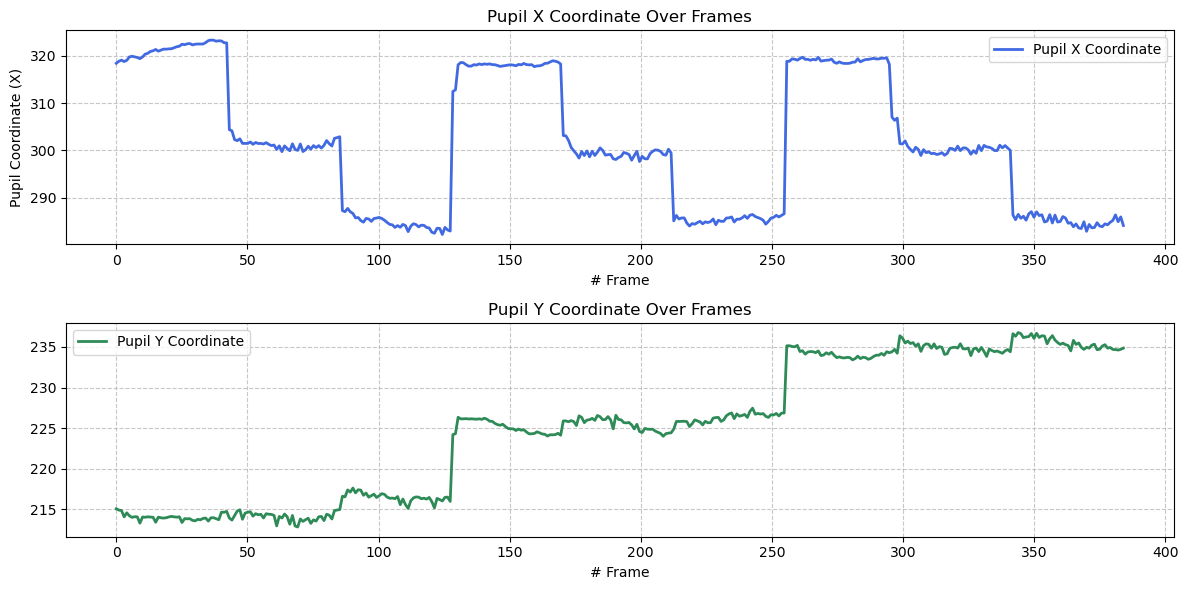

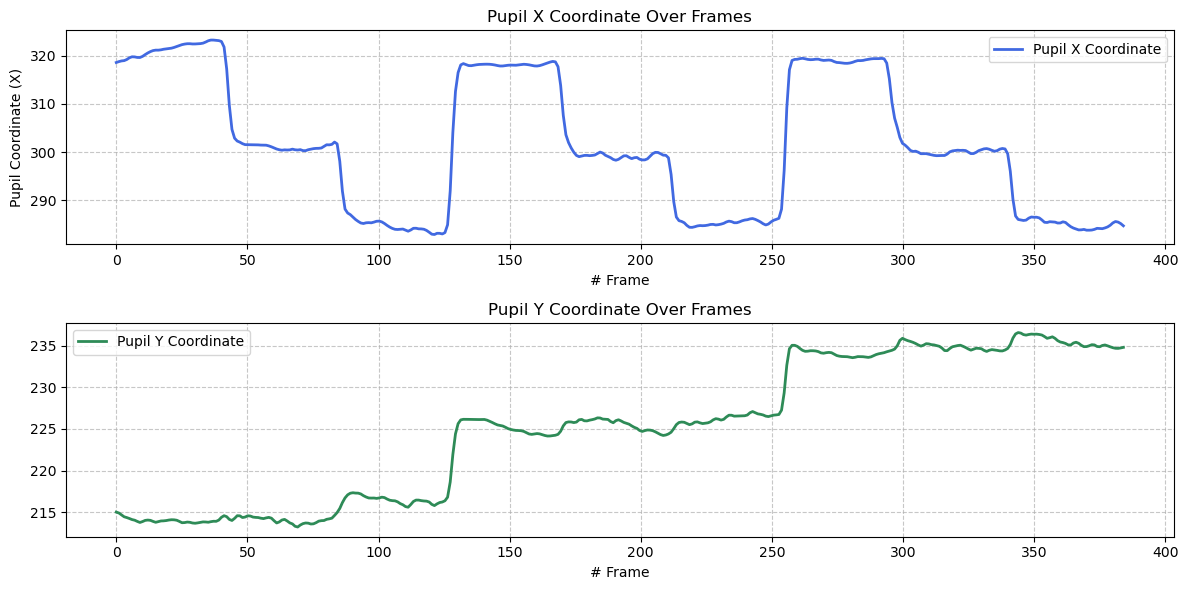

In [ ]:
def convolve_gauss(data, sigma = 1):
    filtered = gaussian_filter1d(data, sigma=sigma, order = 0)
    return filtered


px = np.asarray(pupil_coor['px'])
py = np.asarray(pupil_coor['py'])

# Write your implementation
filtering_util.plot_x_and_y(px, py)

sigma = 1 # Determines how much smoothing is applied
filtered_x = convolve_gauss(px, sigma)
filtered_y = convolve_gauss(py, sigma)

filtering_util.plot_x_and_y(filtered_x, filtered_y)


---
**Task 4 (easy): Reflect on applying gaussian filter👩‍💻💡**
1. Characterize the signal and the noise. 
2. Experiment with the `sigma`
 parameter, which value of sigma removes the noise, but maintains the signal? 
3. Explain the effect of changing `sigma`
 on the data.
4. For which value of `sigma`
 does the important features of the signal start to disappear?


---

In [459]:
#Write your reflections here...

# 1 
# The signal is the clear drops/peaks in the data that represent actual gaze movements,
# while the noise is the rapid fluctuations and irregularities that do not correspond to real movements (small ups and downs).

# We know that this particular data is from the grid pattern where the gaze should look on a grid of 3x3 points,
# We can see this in the plots, where we can identify the main gaze movements as larger shifts in the x and y coordinates,
# while the smaller, rapid fluctuations are likely noise.
# In the x-coordinate plot, we can see three sets of three drops corresponding to the movement between the three points in each of the three rows, 
# and between each set of three drops in the x-coordinate, there is a rise in the y-coordinate representing the movement vertically to the next row. 


# 2
# I belive sigma 2 is reasonable here, as it smooths out a lot of the noise while still preserving the main gaze movements, but I had a hard time deciding the exact value.


# 3
# The bigger sigma gets, the smoother the data becomes, but the more detail is lost.
# A very high sigma (e.g., 10) would oversmooth the data, losing important gaze details.
# A very low sigma (e.g., 0.5) would not effectively reduce noise.
# What is lost first is the timing of the saccades and small fixations, as they get blurred out with higher sigma values.

# 4
# It is gradually more difficult to see the exact points where gaze shifts occur as sigma increases,
# and especially the timing of the shifts quickly becomes unclear.
# When sigma is 10, it is very hard to identify the exact moments of gaze shifts, as the data is heavily smoothed.
# Here, the shift on the x-coordinate just before frame 50 is almost unrecognizable.


## Partials derivatives

---
**Task 5 (easy): Partial derivatives💡📽️**
1. Recall from the lecture the partial derivatives of a signal calculated by convolving using the filter `[-1, 1]`
. What would be the result of convolving with a derivative filter on data that has been smoothed by a Gaussian filter? Use the following questions to guide your answers:    
 - Why does this filter find the derivative of the signal?
 - Which information is gained by applying such filter to gaze data?
 - How can the output be used for further processing?
 - What is the influence of the `sigma` value in the Gaussian the filter when finding the partial derivatives?

---

In [460]:
#Write your reflections here...
# 1. Recall from the lecture the partial derivatives of a signal calculated by convolving using the filter `[-1, 1]`. 
# What would be the result of convolving with a derivative filter on data that has been smoothed by a Gaussian filter? 
# Use the following questions to guide your answers:    
# - Why does this filter find the derivative of the signal?
# - Which information is gained by applying such filter to gaze data?
# - How can the output be used for further processing?
# - What is the influence of the `sigma` value in the Gaussian filter when finding the partial derivatives?

# 1
# The filter [-1, 1] approximates the first derivative of a signal by calculating the difference between consecutive data points.
# This difference represents the rate of change of the signal at each point, and thereby gives an indication of when the gaze is moved.
# When applied to smoothed data (which has been smoothed by a Gaussian filter), it still captures the rate of change,
# but the noise reduction from the Gaussian filter helps to ensure that the derivative reflects true signal changes
# rather than rapid fluctuations caused by noise.
# After applying the derivative filter to the smoothed gaze data, the movements of the gaze will be clear as peaks in the output signal,
# while small fluctuations due to noise will be minimized thanks to the prior smoothing.
# The influence of the sigma value in the Gaussian filter is thereby seen in the derivative output:
# A larger sigma results in a smoother signal, which leads to a cleaner derivative output that highlights
# significant gaze movements while suppressing noise-induced variations. But it should not be too large,
# as that could oversmooth the data and lead to loss of important details.

The following task is about implementing a method to find derivatives a signal using the filter $[-1, 1]$. 
The function `plot_x_and_y_complete`
 from `filter_util.py`
 takes two dictionaries one for each coordinates and plots the signals. The dictionaries should contain keys value pairs of the original and processed signal. 

---
**Task 6 (easy): Calculate the derivatives👩‍💻**
1. Complete the function `get_partial_derivatives`
 to apply the derivative filter to a signal and return the absolute value of the result. Use [np.convolve](https://numpy.org/doc/2.0/reference/generated/numpy.convolve.html)
 for convolution. The **absolute value** of the derivative is used as only the rate of change is of interest. 


---

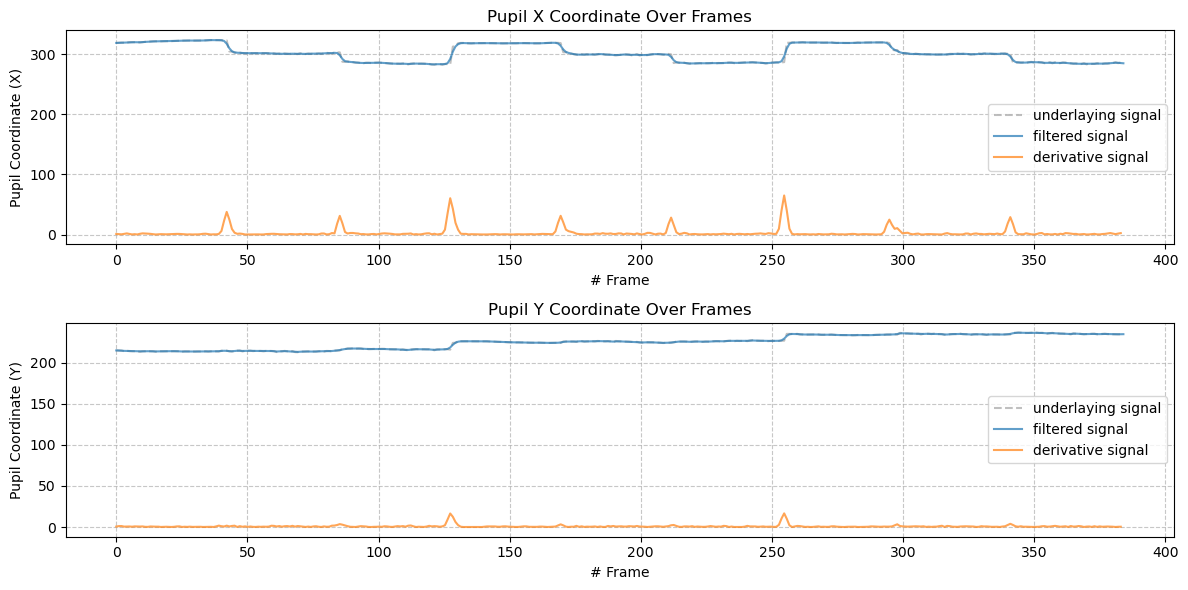

In [461]:
def get_partial_derivatives(data):
    """
    Convolve 1D data with a [-1, 1] filter.

    Args:
        data (numpy array): 1D array of data.

    Returns:
        numpy array: Convolved result.
    """
    # Write your implementation
    filter = np.array([-1, 1])
    derivative = np.convolve(data, filter, mode='valid') # the mode 'valid' means that only points where the filter fully overlaps with the data are considered
    abs_derivative = np.abs(derivative)
    return abs_derivative

der_x = get_partial_derivatives(filtered_x)
der_y = get_partial_derivatives(filtered_y)

x_collected = {'underlaying': px, 'filtered': filtered_x, 'derivative': der_x}
y_collected = {'underlaying': py, 'filtered': filtered_y, 'derivative': der_y}

filtering_util.plot_x_and_y_complete(x_collected, y_collected)


---
**Task 7 (easy): Derivatives of a signal💡📽️**
1. Inspect the plots above and reflect on the relation between the original signals, the filtered and the derivative of the filtered signals. In your reflections you may include:    
    - What charateristics in the gaze data do the peaks and plateaus encapsulate, use the data collection session to elaborate. 
    - What behaviour is expected for the `x` coordinate of the pupil?
    - What behaviour is expected for the `y` coordinate of the pupil?
    - What would happen with these if if the pattern was changed?

---

In [462]:
#Write your reflections here...

# 1. Inspect the plots above and reflect on the relation between the original signals, the filtered and the derivative of the filtered signals. 
# In your reflections you may include:    
#    - What charateristics in the gaze data do the peaks and plateaus encapsulate, use the data collection session to elaborate. 
#    - What behaviour is expected for the `x` coordinate of the pupil?
#    - What behaviour is expected for the `y` coordinate of the pupil?
#    - What would happen with these if the pattern was changed?

# 1
# The original signals contain a lot of noise, making it difficult to discern actual gaze movements.
# The filtered signals smooth out this noise, revealing the underlying gaze movements more clearly.
# The derivative of the filtered signals highlights the points where the gaze changes direction or speed,
# appearing as peaks in the derivative plots.
# When the gaze is stable (fixating), the derivative is low (plateaus),
# while rapid movements (saccades) produce high derivative values (peaks).

# For the x coordinate of the pupil, we expect peaks to appear when the gaze moves left or right.
# For the y coordinate, we expect peaks to appear when the gaze moves up or down.
# If the pattern was changed, we would expect the characteristics of the gaze data to change accordingly
# e.g., looking at the data from the line pattern (a horizontal line) instead of the grid pattern would likely produce more horizontal movements (x changes) and fewer vertical movements (y changes).
# So the derivative plots would reflect these changes with more pronounced peaks in the x derivative and fewer (none if the angle is perfect and all noise is removed) in the y derivative.



The following task are about detecting events (fixations and saccades) in eye signals using derivative filters.

---
**Task 8 (easy): Saccade detection👩‍💻**
1. Complete the function `saccade_detection`
. The function should identify indices for _saccades_ (large eye movements) using the derivatives of the smoothed signal.
2. Use the function `saccade_detection`
 to detect saccades in `der_x`
 and `der_y`
.


---

In [463]:
def saccade_detection(signal, threshold=3.0):
    """
    Saccade detection: 
        Mark indices where the signal exceeds a threshold.

    Parameter:
        signal (list): derivative signal
        threshold (float): threshold marking a spike in the signal
    

    return: list of saccade indices
    """
    
    saccades = []
    for i, v in enumerate(signal):
        if v > threshold:
            saccades.append(i)
    return saccades

x_saccades = saccade_detection(der_x, threshold=3)
y_saccades = saccade_detection(der_y, threshold=3)


---
**Task 9 (easy): Saccade detection👩‍💻**
1. Run the cell below to visualize the detected saccades.


---

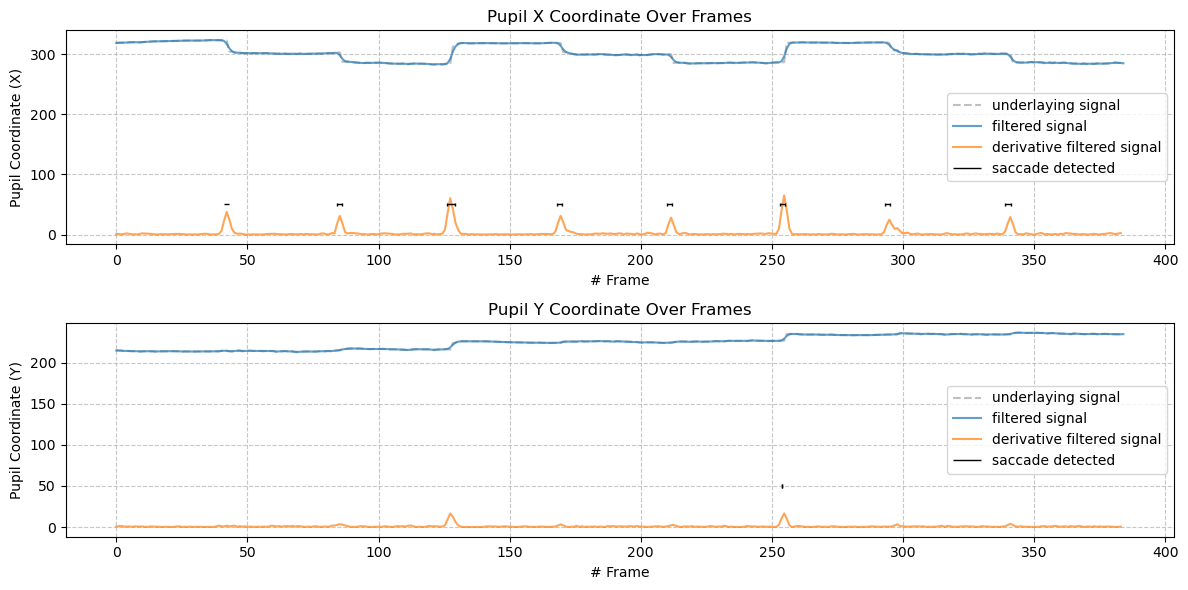

Saccades in x at indices: [41, 42, 43, 84, 85, 86, 126, 127, 128, 129, 168, 169, 170, 210, 211, 212, 253, 254, 255, 293, 294, 295, 339, 340, 341]
Saccades in y at indices: [127, 254]


In [464]:
x_saccade = {'underlaying': px, 'filtered': filtered_x, 'derivative filtered': der_x, 'saccade': x_saccades}
y_saccade = {'underlaying': py, 'filtered': filtered_y, 'derivative filtered': der_y, 'saccade': y_saccades}

filtering_util.plot_x_and_y_complete(x_saccade, y_saccade)
print(f'Saccades in x at indices: {x_saccades}')
print(f'Saccades in y at indices: {y_saccades}')


---
**Task 10 (easy): Fixation detection👩‍💻**
This task is about using the saccades to identify individual fixation points.
1. Complete the function `fixation_filtering`
. The function should use the output of the `saccade_detection`
 to remove all saccades by overwriting the saccade indices with the latest known fixation point.

**Note:** This may not be the most optimal way of handling saccades, but it serves the purpose of this exercise

`fixation_filtering`
`get_partial_derivatives`
`saccade_detection`

---

In [465]:
def fixation_filtering(px, py, x_saccades, y_saccades):
    """
    Removes saccades from the input data based on detected indices for saccades. If a spike is detected
    at a given index, the previous valid fixation value is used to replace the current value.
    Parameters:
        px (1 x N nupy array): Representing the x coordinates (input signal).
        py (1 x N nupy array): Representing the y coordinates (input signal).
        x_saccades (list): A list of indices where saccades are detected in the x direction.
        y_saccades (list): A list of indices where saccades are detected in the y direction.
    Returns:
    px_new (list): A list of the cleaned x coordinates.
    py_new (list): A list of the cleaned y coordinates.
    """
    px_cleaned = []
    py_cleaned = []
    # Write your implementation
    for i in range(len(px)):
        if i in x_saccades:
            px_cleaned.append(px_cleaned[-1])  # Replace with last valid fixation value
        else:
            px_cleaned.append(px[i])  # Keep original value

        if i in y_saccades:
            py_cleaned.append(py_cleaned[-1])  # Replace with last valid fixation value
        else:
            py_cleaned.append(py[i])  # Keep original value

    return px_cleaned, py_cleaned


cleaned_px, cleaned_py = fixation_filtering(px, py, x_saccades, y_saccades)
der_x_cleaned = get_partial_derivatives(cleaned_px)
der_y_cleaned = get_partial_derivatives(cleaned_py)
x_saccades_cleaned = saccade_detection(der_x_cleaned, threshold=3)
y_saccades_cleaned = saccade_detection(der_y_cleaned, threshold=3)


---
**Task 11 (easy): Visualization of signals👩‍💻**
1. Run the cell below to visualize the fixations and saccades.


---

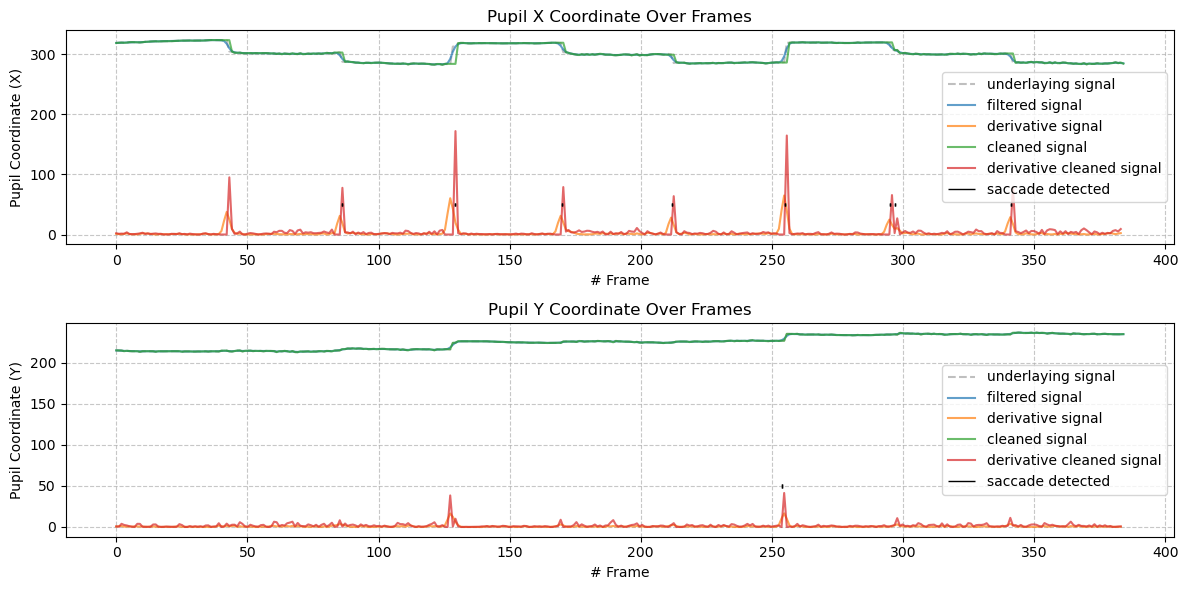

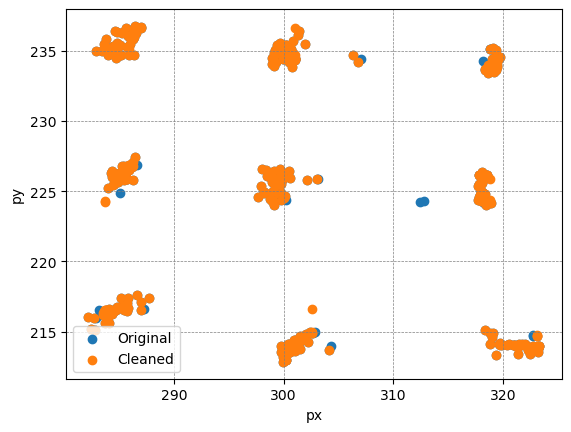

In [466]:
x_collected['cleaned'] = cleaned_px
y_collected['cleaned'] = cleaned_py

x_collected['derivative cleaned'] = der_x_cleaned
y_collected['derivative cleaned'] = der_y_cleaned

x_collected['saccade detected'] = x_saccades_cleaned
y_collected['saccade detected'] = y_saccades_cleaned

filtering_util.plot_x_and_y_complete(x_collected, y_collected, 5) #5 is a scaling factor on the values of the derivative for display purposes
filtering_util.plot_pupil_coor(px, py, 'Original')
filtering_util.plot_pupil_coor(cleaned_px, cleaned_py, 'Cleaned')
plt.show()


---
**Task 12 (easy): Noise handling during fixations💡📽️**
1. Reflect on the assumptions of your method for handling noise during fixations in [Task 10](#fixations1). What are the advantages and limitations of your approach if any?
2. Reflect on other strategies that you could use for handling the noise and outliers in the gaze data.


---

In [ ]:
#Write your reflections here...

# 1. Reflect on the assumptions of your method for handling noise during fixations in [Task 10](#fixations1). 
# What are the advantages and limitations of your approach if any?

# The assumption is that during fixations, the gaze position should remain relatively stable,
# and changes in gaze position that exceed a certain threshold are due to saccades.
# I also assume that between each fixation, there is a saccade of at least one data point.
# Small fluctuations within the threshold are considered part of the fixation,
# while larger changes indicate a saccade.
# Advantages: 
    # The detected points of fixation are more likely to represent true gaze positions,
    # as saccades are removed, leading to a cleaner dataset for analysis.
# Limitations: 
    # The method relies on the accuracy of saccade detection.
    # If the threshold is not well-chosen, it may either miss saccades (false negatives) or incorrectly classify fixations as saccades (false positives).
    # Additionally, replacing saccade points with the last valid fixation value may introduce misrepresentations of the gaze position,
    # especially if saccades occur frequently or if the gaze is rapidly changing. (the last valid fixation value may not be representative of the true gaze position after a saccade).

# 2. Reflect on other strategies that you could use for handling the noise and outliers in the gaze data.

# Maybe looking at time windows of fixations - where the eye have had time to stabilise after a saccade - and only consider those points as valid fixations.
# And then choose the median or mean of those points as the fixation point.


The next step is to utilize the charateristics of the derivative of the smoothed signal to detect the frames (pupil coordinates) corresponding to each screen calibration point, so the data can be sorted in corresponding input and label pairs.

---
**Task 13 (easy): Frame grouping👩‍💻**
1. Complete the function `get_frames_pupil_movement`
. The function should construct a dictionary where the keys represent the calibration point numbers (e.g., '0', '1', ..., '8'), and the associated values are tuples consisting of the start and end frame indicies.
2. Use the function `get_frames_pupil_movement`
 to determine the sections pupil corrdinate sections belonging to each calibration coordinate.


---

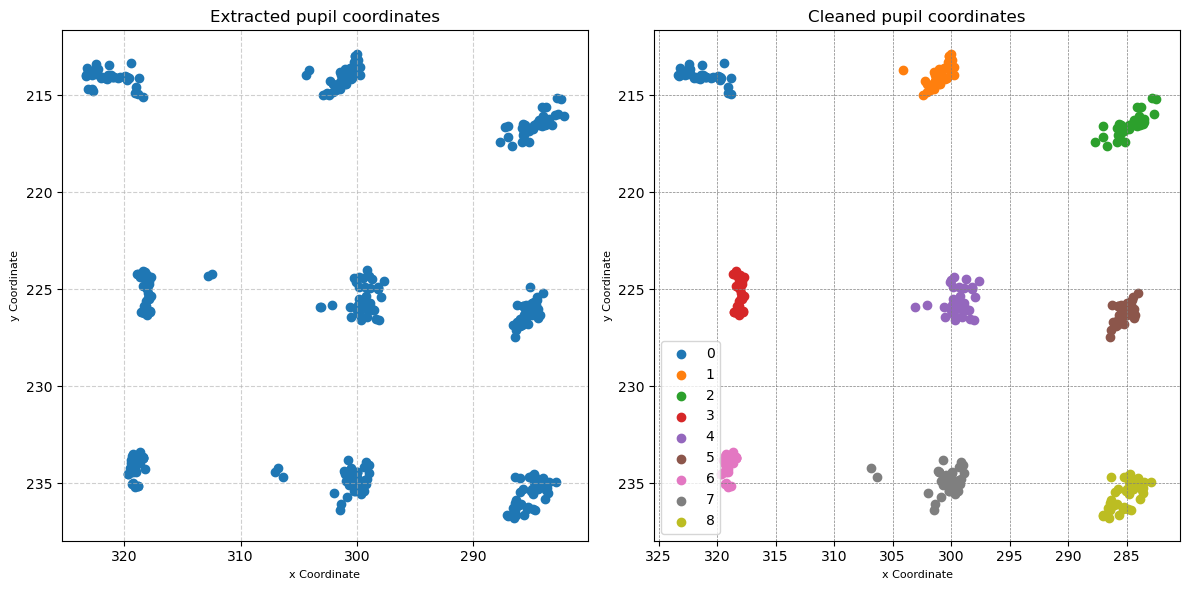

In [468]:
def get_frames_pupil_movement(cleaned_der, data):
    """
    Identifies segments of pupil movement based on changes in the cleaned derivative.
    Parameters:
        cleaned_der (list or numpy array): A 1D array of the derivative values of the cleaned data, indicating changes in pupil position over time.
        data (list or numpy array): The original data corresponding to the pupil movement.

    Returns:
        dict ( {string: tuple(int, int)} ): A dictionary where the keys are calibration point numbers (as strings) and the values are tuples
              containing the start and end frame numbers for each segment.
    """
    frames = {}
    start = None
    end = None
    point_number = 0
    for i in range(len(cleaned_der)):
        if cleaned_der[i] > 0:  # Movement detected
            if start is None:
                start = i+1 # Mark the start frame of the movement (If this is the first frame of movement). 
                            # Since the derivative array computes >0 if there is movement between frame i and i+1, we set start to i+1 (as the movement starts somewhere between these frames and so we only know it started after frame i and before or at frame i+1)
            end = i # The movement continues, so we update the end frame
        else:  # No movement
            if start is not None and end is not None: # We were in a movement segment and now it has ended
                frames[str(point_number)] = (start, end) 
                point_number += 1
                start = None
                end = None
            else:
                continue  # Still not in a movement segment
    # Handle case where movement continues till the end of the data
    if start is not None and end is not None:
        frames[str(point_number)] = (start, end)
    return frames

# Write your implementation
frames = get_frames_pupil_movement(der_x_cleaned, cleaned_px) # We use x and not y here, as the x coordinate has the most movement in this pattern. The y coordinate is mostly stable except when moving between rows (every third point), whereas the x coordinate changes for every point.
filtering_util.plot_pupil_coordinates(frames, px, py, cleaned_px, cleaned_py)

## Analyzing results
In the following task the results of the filtering will be compared to the fixation identification made by the data collection script.

---
**Task 14 (easy): Analyse results👩‍💻**
1. Complete the function `evaluate_fixations_accuracy`
. The function should evaluate the fixation intervals from the filtering the signal, with the fixation noted during the datacollection. 
**Note:** During data collection, the frames are stored with naming `xx_yyyyyy.jpg`
 where xx marks the fixation the gaze in the frame belongs to.


2. Run the cell below to assess the performance of the filtered gazesignal separating fixation. 


---

Sample-level accuracy: 0.9943
Interval-level accuracy: 8/9 = 0.8889


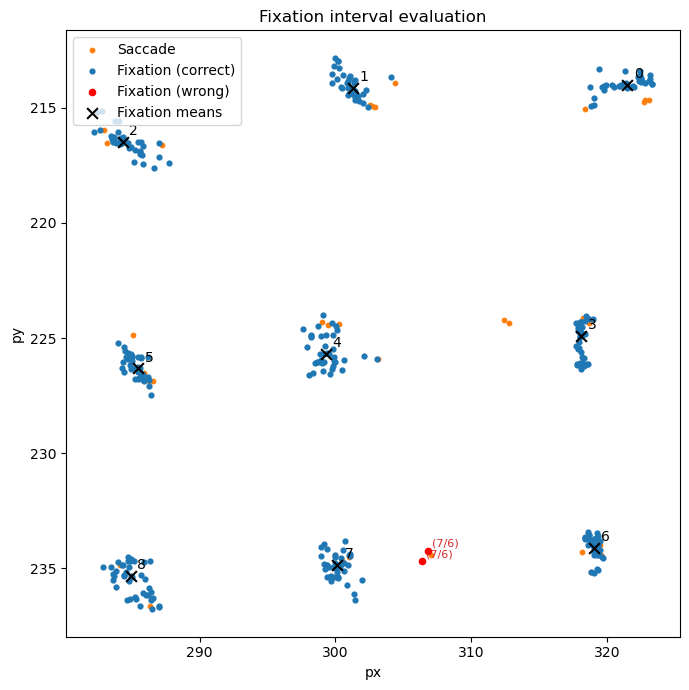

In [475]:
def evaluate_fixations_accuracy(pupil_csv_path, frames_interval):
    """
    Evaluate sample-level accuracy of predicted fixation intervals.

    Parameters:
    csv_path : str
        Path to CSV file with pupil data. Must contain 'image' column
        where the first two characters encode the true fixation ID.
    frames_interval : frames dict
        Mapping of predicted fixation IDs to index ranges,
        e.g. {'0': (0,42), '1': (44,85), ...}.

    Returns:
    None
        Prints the sample-level accuracy (float between 0 and 1).
    """
    df = pd.read_csv(pupil_csv_path) # Load the CSV file into a DataFrame 
    df['true_fix'] = df['image'].str[:2].astype(int) # Extract true fixation IDs from 'image' column. (the image names are in the format `xx_yyyyyy.jpg` where xx is the fixation ID and :2 gets the first two characters)
    # Each row in the DataFrame now has a 'true_fix' column indicating the true fixation ID belonging to that frame.

    total_correct = 0
    total_count = 0
    interval_matches = 0
    interval_total = 0
    # Write your implementation
    for fix_id, (start, end) in frames_interval.items():
        fix_id_int = int(fix_id)
        interval_total += 1
        interval_df = df.iloc[start:end+1] # Get the subset of the DataFrame for the current fixation interval
        correct_count = (interval_df['true_fix'] == fix_id_int).sum() # Count how many samples in this interval match the predicted fixation ID
        total_correct += correct_count
        total_count += len(interval_df)
        if correct_count == len(interval_df):
            interval_matches += 1
    sample_accuracy = total_correct / total_count
    print(f'Sample-level accuracy: {sample_accuracy:.4f}')
    print(f'Interval-level accuracy: {interval_matches}/{interval_total} = {interval_matches/interval_total:.4f}') #This is not part of the task, but I added it to get a better understanding


evaluate_fixations_accuracy(pupil_coordinates, frames)

filtering_util.plot_fixation_eval(pupil_coordinates, frames, mean_pupil_coordinates)
# Errors are noted as pred_fix/true_fix


---
**Task 15 (easy): Evaluate👩‍💻**
1. Inspect accuracy and the plot. Describe the points that were misclassified. Reason about the cause of the missclassification.


---

In [ ]:
# Write your reflections here...
#1. Inspect accuracy and the plot. Describe the points that were misclassified. Reason about the cause of the missclassification.
# The misclassified points are primarily located at the transitions between fixation points, which makes sence as these are probably just saccades wrongly classified as part of the fixation.
# In the initial graphs, we see that between fixation 6 and 7, there is a small hesitation in both the x and y coordinates, where the gaze fixates briefly before moving to the next point (and generally moving slower than for the other saccades). 
# This small hesitation could maybe have been misinterpreted as the ending of the saccade such that the last part of the saccade was classified as part of the next fixation instead of being removed as saccade.
# The image of the misclassification seems to be taken during this hesitation, which could explain why some frames from fixation 6 are misclassified as fixation 7.

# By changing the threshold to 1.5 instead of 3 we get the below results:
# Sample-level accuracy: 1.0000
# Interval-level accuracy: 9/9 = 1.0000
# (+ See image below)

# Regarding the yellow points (saccades) in the plot, most of them are far from the fixation points,
# indicating that the saccade detection is effectively identifying rapid eye movements away from the fixation points.
# However, a few yellow points are quite close to the fixation points, which could suggest that they actually belong to the fixation periods rather than being true saccades.
# This could be due to the threshold being too low, causing minor fluctuations during fixations to be misclassified as saccades, or they might just be part of a saccade, but happening very close to the fixation point (in the beginning/end of the saccade).
# In the image below, where the threshold is even lower (1.5) than in the plot above (3), we see that a few more of the points are turned yellow (In the middle column in the top row, in the middle row in the middle column and the earlier misclassified points between fixation 6 and 7).
# All of those are located in the outer region of the fixations, indicating that they are likely part of the saccade movements rather than true fixations. We do not get more yellow points close to the fixation centers, which is good, and which indicates that the lower threshold is not causing misclassification of fixation points as saccades, but that the points we where worried about before, probably also are true saccade points.

![outputLowerThresholds](outputLowerThreshold.png)

## Inspecting own data

---
**Task 16 (medium): Combined signal👩‍💻💡**
1. Go back to [Task 1](#task_load_data) and update the folder path to target the `grid`
 pattern of your own data.
2. Rerun the steps above.
3. Reflect on how well does the method generalizes to this dataset. You may use the following questions to guide your answers?    
    - How do the results differ from the ones of `test_subject_1`?
    - Is it possible to reuse the same parameters or do they need to be updated?
    - Has the experimental setup any influence on the methods ability to generalizable? Why/why not?




---

In [ ]:
# Write your reflections here...

# 1 ...
# 2 ....
# 3 
# The choice of threshold in the saccade detection step significantly impacts the accuracy of fixation classification.
# A lower threshold (e.g., 1.5) allows for more sensitive detection of saccades,
# which can help in accurately identifying the transitions between fixations.
# This sensitivity can lead to improved classification accuracy, as seen in the results above,
# where all fixations were correctly identified with a threshold of 1.5.
# However, setting the threshold too low may also risk misclassifying minor fluctuations during fixations
# as saccades, potentially leading to over-segmentation of the data.
# Using the same threshold value across different datasets may not yield consistent results,
# as the characteristics of gaze data can vary based on factors such as the experimental setup,
# participant behavior, and noise levels.
# This makes generalization challenging, and it may be necessary to tune the threshold for each specific dataset 
# or first normalize the data to ensure consistent saccade detection performance.

## Event detection using gradients
In this task you will explore the combined signal (changes in x and y direction simultainously) and use the gradient for event detection. Recall the definition for the gradient of the function $f(x,y)$:

$$

\nabla f(x, y) = \left( \frac{\partial f(x,y)}{\partial x}, \frac{\partial f(x,y)}{\partial y} \right)


$$

You will use the gradient magnitude, the length of the gradient defined by:

$$
||\nabla f(x, y)|| = \sqrt{\Big(\frac{\partial f(x,y)}{\partial x}\Big)^2 + \Big(\frac{\partial f(x,y)}{\partial y} \Big)^2}
$$

---
**Task 17 (easy): Combined signal👩‍💻**
1. Complete the functions:    
    - `gradient_mangitude`: The function should calculate the gradient magnitude of a $2D$ signal given `x` and `y`.




---

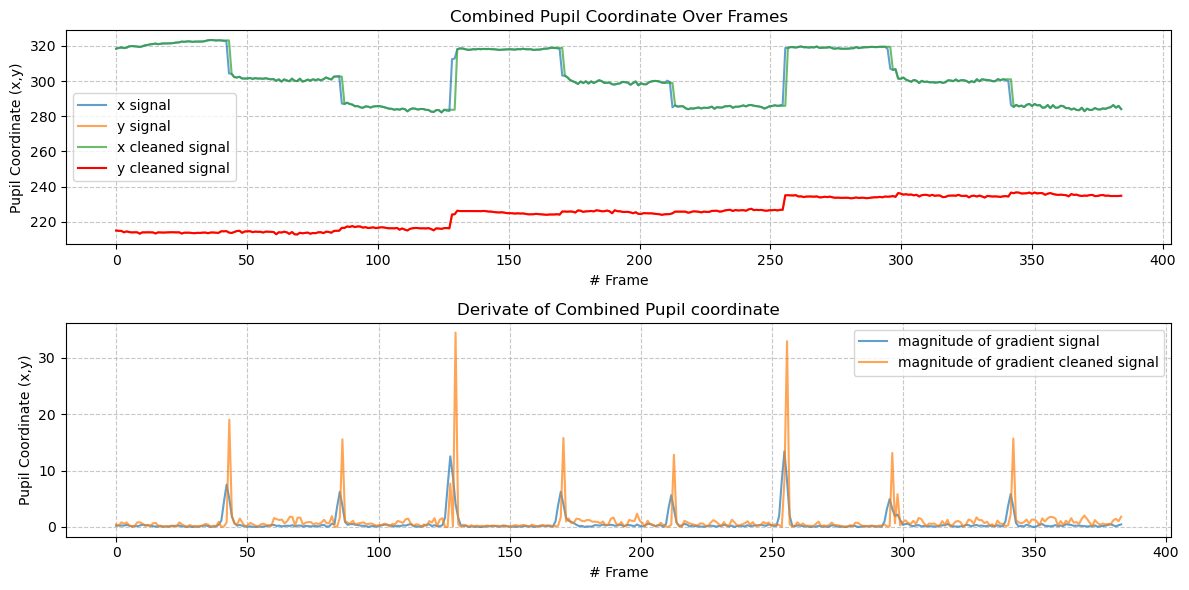

In [477]:
def gradient_mangitude(x,y):
    """
    Calculates the gradient mangitude in a 2D space.
    Args:
        x (N x 1 numpy array): Array of x coordinates.
        y (N x 1 numpy array): Array of y coordinates.
    
    Returns:
        (N x 1 numpy array): The Euclidean distance from the origin to the point (x, y).
    """
    # Write your implementation
    magnitude = np.sqrt(np.square(x) + np.square(y))
    return magnitude

magnitude = gradient_mangitude(der_x, der_y)
magnitude_cleaned = gradient_mangitude(der_x_cleaned, der_y_cleaned)

collected_signal = {}
collected_magnitude = {}
collected_signal['x'] = px
collected_signal['y'] = py
collected_signal['x cleaned'] = cleaned_px
collected_signal['y cleaned'] = cleaned_py
collected_magnitude['magnitude of gradient'] = magnitude
collected_magnitude['magnitude of gradient cleaned'] = magnitude_cleaned



filtering_util.plot_x_and_y_combined(collected_signal, collected_magnitude, 5) #5 is a scaling factor on the values of the derivative for display purposes


---
**Task 18 (easy): Reflect💡**
1. Reflect on the benefit of using the combined signal compared to using the two individual signals.


---

In [0]:
# Write your reflection here...

# Using the combined signal (gradient magnitude) captures changes in both x and y directions simultaneously.
# This is particularly beneficial in scenarios where gaze movements are not strictly horizontal or vertical,
# as it allows for the detection of diagonal movements and more complex patterns.
# And when movement happens in only one direction (x or y), the combined signal still reflects this movement, 
# and might help explain an increase in the noise level in the other direction while moving.